In [1]:
import gc
gc.collect()

36

# elevator-rmnd

Use the simulated dataset generated by `dataset.py` to train
regression models, in order to predict the remaining useful life (RUL)
of lifts.

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(context="notebook", style="ticks")

## preprocessing
* Import the simulated dataset
* Convert lift ids to integers
* ~~Compute instantaneous time derivatives of each sensor metric~~ [called off for now]
* Compute RUL in h
* Split data into training/testing sets
* Scale data with a `Scaler`

In [3]:
df_full = pd.read_pickle("predictive_maintenance_lifts.pkl")
df_full.head(10)

,timestamp,lift_id,lift_model,lift_age_hours,ARM_DIST_mm,DOOR_DIST_mm,FLOOR_DIST_mm,ROPE_MFL_mV,BEARING_TEMP_C,maintenance_done,RUL_hrs
0,2023-01-01 00:00:00,1,Otis Gen2,15000,0.506,2.101,0.116,9.737,34.429,0,996.0
1,2023-01-01 12:00:00,1,Otis Gen2,15012,0.486,1.811,0.288,10.476,33.628,0,984.0
2,2023-01-02 00:00:00,1,Otis Gen2,15024,0.500,2.070,0.056,9.066,34.675,0,972.0
3,2023-01-02 12:00:00,1,Otis Gen2,15036,0.525,2.472,0.373,10.265,34.941,0,960.0
4,2023-01-03 00:00:00,1,Otis Gen2,15048,0.506,2.383,0.451,9.954,34.587,0,948.0
5,2023-01-03 12:00:00,1,Otis Gen2,15060,0.519,2.307,0.490,10.225,36.151,0,936.0
6,2023-01-04 00:00:00,1,Otis Gen2,15072,0.501,2.541,1.145,11.004,36.132,0,924.0
7,2023-01-04 12:00:00,1,Otis Gen2,15084,0.549,2.403,0.371,10.862,35.528,0,912.0
8,2023-01-05 00:00:00,1,Otis Gen2,15096,0.509,2.488,0.559,10.610,36.800,0,900.0
9,2023-01-05 12:00:00,1,Otis Gen2,15108,0.558,2.738,1.035,10.507,35.747,0,888.0


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

Since there exist rows that have `np.inf` as their predicted RUL, extract those rows for experimentation later on.
Retain the remaining roles (with valid RULs) for training and testing.

In [5]:
df_experimental = df_full[
    df_full["RUL_hrs"] == np.inf
]  # Filter out records with no further maintenance
df_useful = df_full[
    df_full["RUL_hrs"] != np.inf
]  # Retain the remaining records for training/testing

# Check to see the experimental/useful split was done correctly
assert all(
    df_experimental["RUL_hrs"] == np.inf
), "All records in experimental set should have RUL_hrs == np.inf"
assert all(
    df_useful["RUL_hrs"] != np.inf
), "All records in useful set should have valid RUL_hrs"

df_useful.head(40)

,timestamp,lift_id,lift_model,lift_age_hours,ARM_DIST_mm,DOOR_DIST_mm,FLOOR_DIST_mm,ROPE_MFL_mV,BEARING_TEMP_C,maintenance_done,RUL_hrs
0,2023-01-01 00:00:00,1,Otis Gen2,15000,0.506,2.101,0.116,9.737,34.429,0,996.0
1,2023-01-01 12:00:00,1,Otis Gen2,15012,0.486,1.811,0.288,10.476,33.628,0,984.0
2,2023-01-02 00:00:00,1,Otis Gen2,15024,0.500,2.070,0.056,9.066,34.675,0,972.0
3,2023-01-02 12:00:00,1,Otis Gen2,15036,0.525,2.472,0.373,10.265,34.941,0,960.0
4,2023-01-03 00:00:00,1,Otis Gen2,15048,0.506,2.383,0.451,9.954,34.587,0,948.0
5,2023-01-03 12:00:00,1,Otis Gen2,15060,0.519,2.307,0.490,10.225,36.151,0,936.0
6,2023-01-04 00:00:00,1,Otis Gen2,15072,0.501,2.541,1.145,11.004,36.132,0,924.0
7,2023-01-04 12:00:00,1,Otis Gen2,15084,0.549,2.403,0.371,10.862,35.528,0,912.0
8,2023-01-05 00:00:00,1,Otis Gen2,15096,0.509,2.488,0.559,10.610,36.800,0,900.0
9,2023-01-05 12:00:00,1,Otis Gen2,15108,0.558,2.738,1.035,10.507,35.747,0,888.0


Then perform a 85/15 train/test split on the remaining useful data.

In [6]:
X = df_useful.drop(columns=["timestamp", "lift_model", "maintenance_done", "RUL_hrs"])
y = df_useful["RUL_hrs"]
X.dtypes, y.dtypes

(lift_id             int64
 lift_age_hours      int64
 ARM_DIST_mm       float64
 DOOR_DIST_mm      float64
 FLOOR_DIST_mm     float64
 ROPE_MFL_mV       float64
 BEARING_TEMP_C    float64
 dtype: object,
 dtype('float64'))

In [7]:
X_learn, X_test, y_learn, y_test = train_test_split(
    X, y, test_size=0.15, random_state=67
)
# Dummy checks
assert len(X_learn) == len(y_learn), "X_learn and y_learn should have the same size"
assert len(X_test) == len(y_test), "X_test and y_test should have the same size"
assert y_learn.isna().sum() == 0, "y_learn should not have any null values"
assert y_test.isna().sum() == 0, "y_test should not have any null values"

Use `StandardScaler` to transform the data (for classical ML techniques).

In [8]:
scaler = StandardScaler()
X_learn = scaler.fit_transform(X_learn)
X_test = scaler.transform(X_test)

## classical ML techniques
We experiment with a few classical regression techniques and evaluate them on a set of metrics.
Metrics of interest include:
* mean absolute error (`mae`): the mean deviation (in h) of predicted RUL from true RUL
* r2 score (`r2`): how well the true RUL and predicted RUL match up

In [9]:
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import ElasticNet

In [10]:
model_architectures = {
    "svr": SVR(kernel="linear", epsilon=0.1),
    "xgb": XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.1),
    "elastic-net": ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=67),
    "hist-gb": HistGradientBoostingRegressor(
        max_iter=100, max_depth=6, learning_rate=0.1, random_state=67
    ),
    "random-forest": RandomForestRegressor(n_estimators=500, max_depth=6),
}

Just carry out model training.
* Record the RMSE, MAE and R2 of each model
* Record each model's $\hat{y}$ for visual comparison

In [11]:
all_metrics, all_preds = [], []

for name, arch in model_architectures.items():
    lift_model = arch
    lift_model.fit(X_learn, y_learn)
    y_pred = lift_model.predict(X_test)

    # Store predictions to the model_preds dataframe
    all_preds.extend(
        {"name": name, "y_test": y_test.iloc[i], "y_pred": y_pred[i], "cv": 0}
        for i in range(len(y_test))
    )

    # Compute metrics
    rmse = np.round(np.sqrt(mean_squared_error(y_test, y_pred)), 4)
    mae = np.round(np.abs(y_test - y_pred).mean(), 4)
    r2 = np.round(r2_score(y_test, y_pred), 4)
    all_metrics.extend(
        [
            {"name": name, "metric": "rmse", "value": rmse, "cv": 0},
            {"name": name, "metric": "mae", "value": mae, "cv": 0},
            {"name": name, "metric": "r2", "value": r2, "cv": 0},
        ]
    )
model_metrics = pd.DataFrame(all_metrics)
model_preds = pd.DataFrame(all_preds)

In [12]:
model_metrics

,name,metric,value,cv
0,svr,rmse,212.3574,0
1,svr,mae,161.1551,0
2,svr,r2,0.7888,0
3,xgb,rmse,79.0519,0
4,xgb,mae,52.5189,0
5,xgb,r2,0.9707,0
6,elastic-net,rmse,210.9734,0
7,elastic-net,mae,162.9180,0
8,elastic-net,r2,0.7915,0
9,hist-gb,rmse,126.0854,0


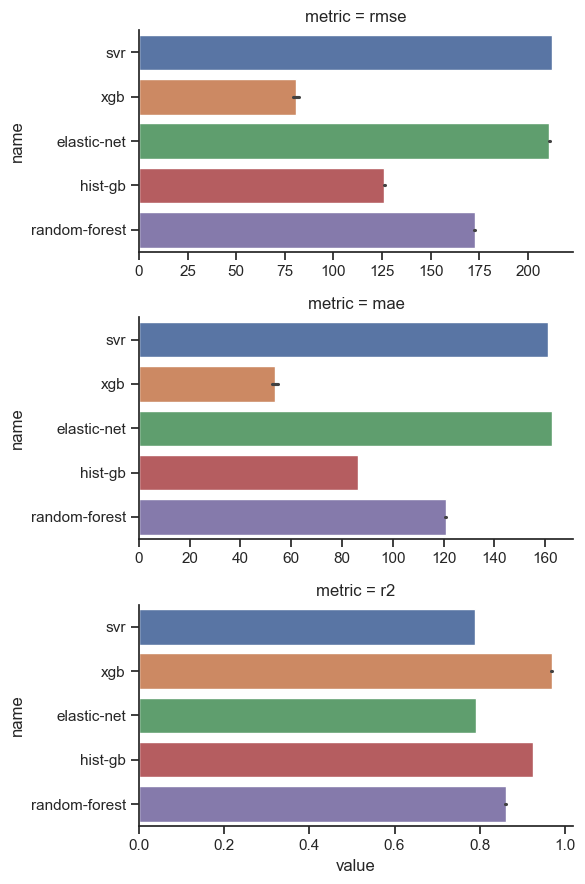

In [37]:
g = sns.FacetGrid(model_metrics, row="metric", sharex=False, height=3, aspect=2, hue="name")
g.map(sns.barplot, "value", "name", order=model_metrics["name"].unique())

<Axes: xlabel='y_test', ylabel='y_pred'>

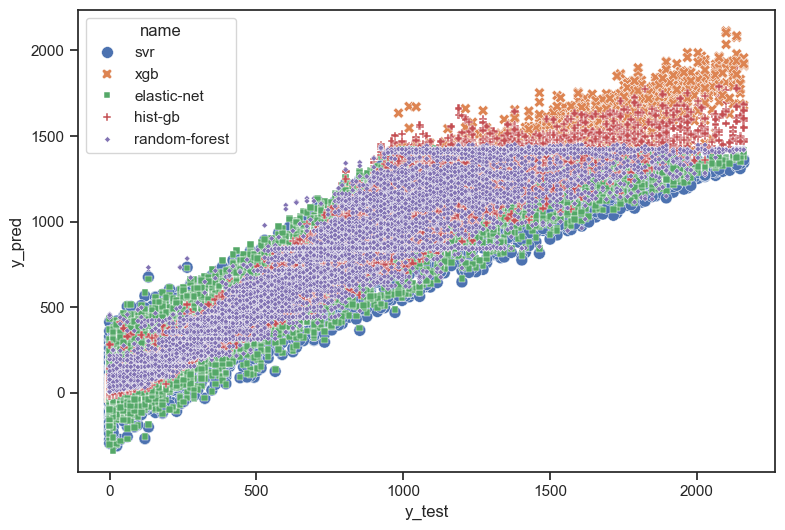

In [34]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=model_preds, x="y_test", y="y_pred", hue="name", size="name", style="name", ax=ax)